# BERTopic Parameter Sweep + Scaled min_cluster_size
## Target: PDF Chunks

This notebook is modularized into separate cells. You can run the heavy parameter sweep, the CSV analysis, and the visualizations individually without re-running the previous steps.

**Note:** PDF chunks contain significantly more data than abstracts. The sweep cell will take a considerable amount of time to run.

In [ ]:
!pip install bertopic umap-learn hdbscan huggingface_hub pandas matplotlib seaborn -q

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from huggingface_hub import hf_hub_download
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# ========================= CONFIG =========================
REPO_ID = "Sakhiur/empirical-rag-paradigm-benchmark"
REPO_TYPE = "dataset"
EMBEDDING_MODEL = "text-embedding-3-small"
CORPUS_TYPE = "pdf_chunks"  # <--- TARGETING PDF CHUNKS

TARGET_CATEGORIES = [
      "cs.IR", "cs.DB", "cs.SE", "cs.CL", "cs.NE", "cs.DC", "cs.CR","cs.AI", "cs.LG", "cs.CV"      
]

# Original scaling logic
MIN_CLUSTER_SIZE_FLOOR = 10
MIN_CLUSTER_SIZE_DIVISOR = 40   

def get_min_cluster_size(population_size: int) -> int:
    return max(MIN_CLUSTER_SIZE_FLOOR, population_size // MIN_CLUSTER_SIZE_DIVISOR)

# Fixed grid for sweeping
FIXED_MIN_CLUSTER_SIZES = [30, 50, 80, 120, 200]

PARAM_GRID = {
     "umap_n_neighbors": [10, 15, 30],
     "umap_n_components": [5, 10],
     "min_samples": [5, 10],
}

RANDOM_STATE = 42

SWEEP_DIR = Path(f"bertopic_sweep_{CORPUS_TYPE}_{EMBEDDING_MODEL}")
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
(SWEEP_DIR / "results").mkdir(exist_ok=True)

### Loaders

In [3]:
def load_embeddings(category: str, corpus_type: str):
    repo_path = f"embeddings/{EMBEDDING_MODEL}/{corpus_type}/{category}.jsonl"
    local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    embeddings = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rec = json.loads(line)
                embeddings[rec["chunk_id"]] = rec["embedding"]
    return embeddings


def load_source_records(category: str, corpus_type: str):
    if corpus_type == "abstracts":
        repo_path = f"abstracts/by_category/{category}.jsonl"
    else:
        repo_path = f"pdf_chunks/{category}.jsonl"
    local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    records = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rec = json.loads(line)
                cid = rec["id"] if corpus_type == "abstracts" else f"{rec['paper_id']}_p{rec['page_num']}"
                records[cid] = rec
    return records


def get_display_text(record, corpus_type):
    return record["text"]

### 1. Run Parameter Sweep (Heavy Computation)
*Run this cell to generate the raw `sweep_results.csv`. This will take a while for PDF chunks.*

In [4]:
results_summary = []

for category in TARGET_CATEGORIES:
    print(f"\n{'='*80}\nSWEEPING {category}\n{'='*80}")
    
    embeddings_dict = load_embeddings(category, CORPUS_TYPE)
    source_records = load_source_records(category, CORPUS_TYPE)
    
    chunk_ids = [cid for cid in embeddings_dict if cid in source_records]
    vectors = np.array([embeddings_dict[cid] for cid in chunk_ids], dtype=np.float32)
    texts = [get_display_text(source_records[cid], CORPUS_TYPE) for cid in chunk_ids]
    n_docs = len(chunk_ids)
    
    scaled_mcs = get_min_cluster_size(n_docs)
    print(f"Documents: {n_docs:,} | Scaled min_cluster_size = {scaled_mcs} (divisor={MIN_CLUSTER_SIZE_DIVISOR})")

    configs_to_try = [scaled_mcs] + FIXED_MIN_CLUSTER_SIZES
    configs_to_try = sorted(set(configs_to_try))

    for mcs in configs_to_try:
        for n_neigh in PARAM_GRID["umap_n_neighbors"]:
            for n_comp in PARAM_GRID["umap_n_components"]:
                for ms in PARAM_GRID["min_samples"]:
                    config_name = f"{category}_mcs{mcs}_nn{n_neigh}_nc{n_comp}_ms{ms}"
                    print(f"  → {config_name}", end="  ")

                    umap_model = UMAP(
                        n_neighbors=n_neigh,
                        n_components=n_comp,
                        min_dist=0.0,
                        metric="cosine",
                        random_state=RANDOM_STATE,
                        low_memory=True
                    )
                    hdbscan_model = HDBSCAN(
                        min_cluster_size=mcs,
                        min_samples=ms,
                        metric="euclidean",
                        cluster_selection_method="eom",
                        prediction_data=True,
                    )

                    topic_model = BERTopic(
                        umap_model=umap_model,
                        hdbscan_model=hdbscan_model,
                        calculate_probabilities=False,
                        verbose=False,
                    )

                    topics, _ = topic_model.fit_transform(texts, embeddings=vectors)

                    topic_info = topic_model.get_topic_info()
                    n_topics = len(topic_info[topic_info["Topic"] != -1])
                    n_outliers = int((np.array(topics) == -1).sum())
                    outlier_pct = 100 * n_outliers / n_docs if n_docs else 0

                    row = {
                         "category": category,
                         "n_docs": n_docs,
                         "min_cluster_size": mcs,
                         "is_scaled": mcs == scaled_mcs,
                         "umap_n_neighbors": n_neigh,
                         "umap_n_components": n_comp,
                         "min_samples": ms,
                         "n_topics": n_topics,
                         "outlier_pct": round(outlier_pct, 2),
                         "config_name": config_name,
                    }
                    results_summary.append(row)

                    if 15 <= n_topics <= 80 and outlier_pct < 45:
                        print(f"✓ SAVED ({n_topics} topics, {outlier_pct:.1f}% outliers)")
                    else:
                        print(f"{n_topics} topics, {outlier_pct:.1f}% outliers")

# Save final results
df = pd.DataFrame(results_summary)
df.to_csv(SWEEP_DIR / "sweep_results.csv", index=False)

print("\n=== SWEEP FINISHED ===")
print(df.groupby("category")[["n_topics", "outlier_pct"]].describe().round(2))


SWEEPING cs.IR
Documents: 1,371 | Scaled min_cluster_size = 34 (divisor=40)
  → cs.IR_mcs30_nn10_nc5_ms5  ✓ SAVED (17 topics, 22.2% outliers)
  → cs.IR_mcs30_nn10_nc5_ms10  ✓ SAVED (17 topics, 23.3% outliers)
  → cs.IR_mcs30_nn10_nc10_ms5  ✓ SAVED (15 topics, 29.5% outliers)
  → cs.IR_mcs30_nn10_nc10_ms10  14 topics, 27.7% outliers
  → cs.IR_mcs30_nn15_nc5_ms5  ✓ SAVED (15 topics, 31.6% outliers)
  → cs.IR_mcs30_nn15_nc5_ms10  14 topics, 34.6% outliers
  → cs.IR_mcs30_nn15_nc10_ms5  12 topics, 22.0% outliers
  → cs.IR_mcs30_nn15_nc10_ms10  12 topics, 22.8% outliers
  → cs.IR_mcs30_nn30_nc5_ms5  14 topics, 29.6% outliers
  → cs.IR_mcs30_nn30_nc5_ms10  10 topics, 23.0% outliers
  → cs.IR_mcs30_nn30_nc10_ms5  13 topics, 29.3% outliers
  → cs.IR_mcs30_nn30_nc10_ms10  4 topics, 0.0% outliers
  → cs.IR_mcs34_nn10_nc5_ms5  ✓ SAVED (15 topics, 24.6% outliers)
  → cs.IR_mcs34_nn10_nc5_ms10  ✓ SAVED (15 topics, 25.7% outliers)
  → cs.IR_mcs34_nn10_nc10_ms5  14 topics, 31.9% outliers
  → cs.IR_m

### 2. Analyze Sweep Results (CSV Processing)
*Run this cell after the sweep is finished to filter and export the best configurations.*

In [5]:
CSV_PATH = SWEEP_DIR / "sweep_results.csv"

if not CSV_PATH.exists():
    print(f"Error: {CSV_PATH} not found. Please run the sweep cell above first.")
else:
    df = pd.read_csv(CSV_PATH)

    print("=== Overall Statistics ===")
    print(df.groupby("category")[["n_topics", "outlier_pct"]].describe().round(2))

    # Filter promising configurations (15-80 topics, <45% outliers)
    promising = df[(df["n_topics"] >= 15) & (df["n_topics"] <= 80) & (df["outlier_pct"] < 45)]

    print("\n=== Promising Configurations (Top 15 overall) ===")
    print(promising.sort_values(by=["category", "outlier_pct"]).head(15))
    
    # Save promising configs to a new CSV
    promising_csv_path = SWEEP_DIR / "promising_configs.csv"
    promising.to_csv(promising_csv_path, index=False)
    print(f"\n✓ Promising configurations saved to {promising_csv_path}")

=== Overall Statistics ===
         n_topics                                            outlier_pct  \
            count   mean   std  min   25%   50%    75%   max       count   
category                                                                   
cs.AI        72.0  12.39  9.19  0.0  4.00  11.5  17.00  31.0        72.0   
cs.CL        72.0   8.22  6.86  0.0  2.00   7.0  16.00  19.0        72.0   
cs.CR        72.0   8.50  4.76  2.0  4.00   8.5  13.00  17.0        72.0   
cs.CV        72.0   6.78  6.02  0.0  2.00   4.0  14.00  17.0        72.0   
cs.DB        72.0   9.61  7.34  2.0  3.00   7.0  14.00  26.0        72.0   
cs.DC        72.0   9.93  5.48  2.0  5.00   9.5  13.00  22.0        72.0   
cs.IR        72.0   6.57  5.03  2.0  2.00   4.0  11.25  17.0        72.0   
cs.LG        72.0  10.56  7.72  2.0  2.75  10.5  15.00  25.0        72.0   
cs.NE        72.0   8.22  7.35  3.0  3.00   4.0  11.25  27.0        72.0   
cs.SE        72.0   9.08  6.08  2.0  3.75   8.5  12.25  22.0 

### 3. Visualize Sweep Results
*Run this cell to generate publication-ready plots showing the trade-offs.*

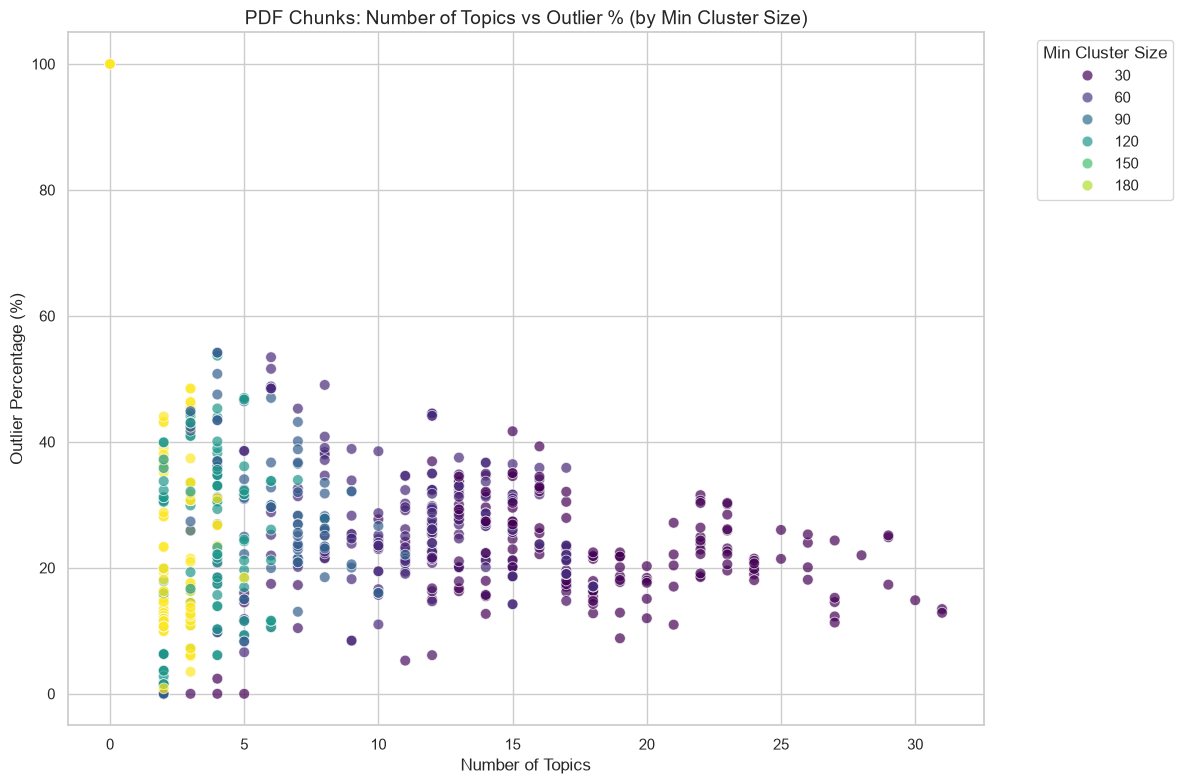

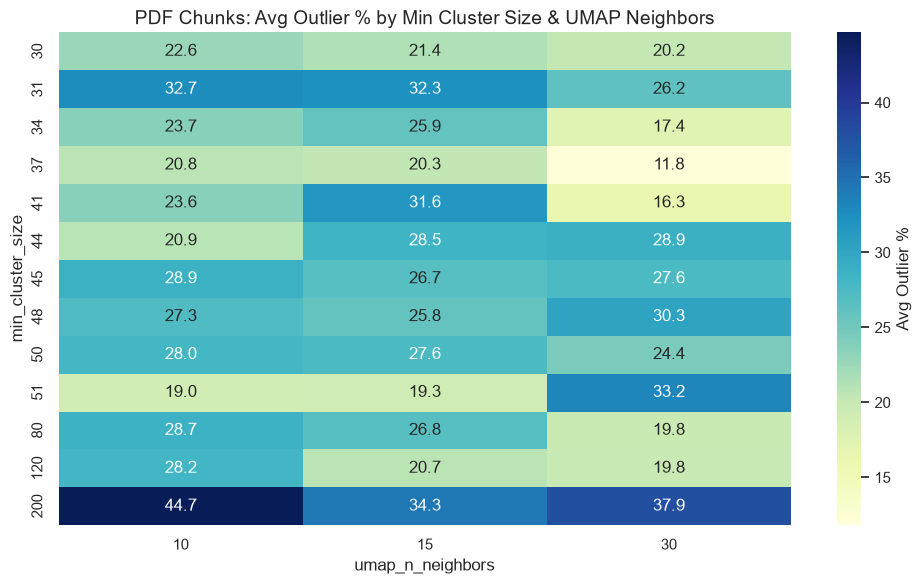

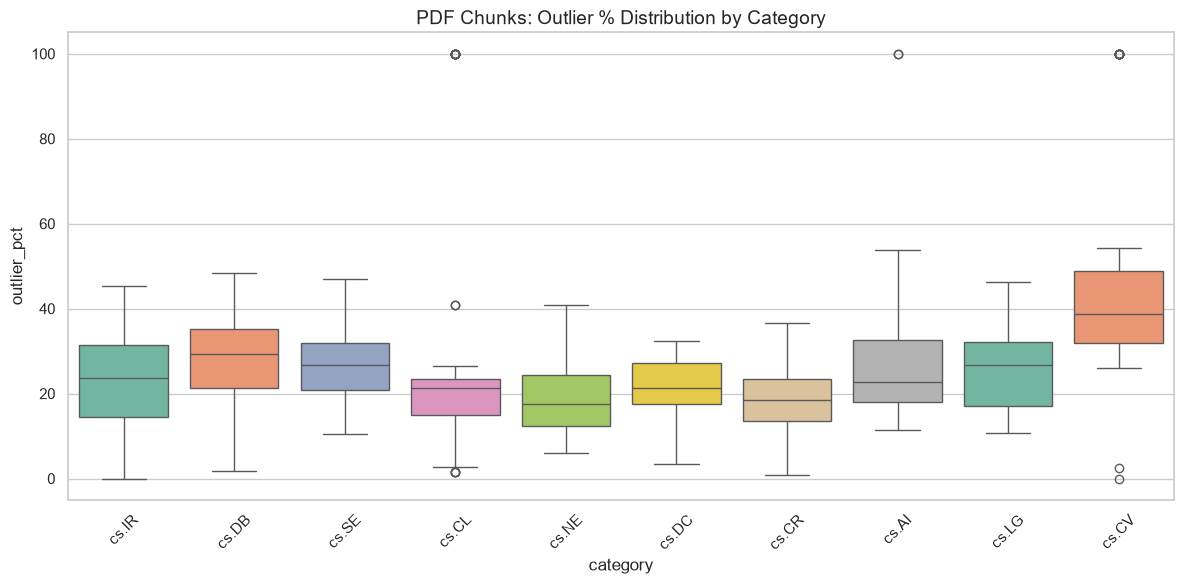

✓ Visualizations saved to bertopic_sweep_pdf_chunks_text-embedding-3-small\visualizations/


In [6]:
CSV_PATH = SWEEP_DIR / "sweep_results.csv"
VIZ_DIR = SWEEP_DIR / "visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_PATH.exists():
    print(f"Error: {CSV_PATH} not found. Please run the sweep cell first.")
else:
    df = pd.read_csv(CSV_PATH)
    sns.set_theme(style="whitegrid")

    # 1. Scatter plot: n_topics vs outlier_pct colored by min_cluster_size
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df, x="n_topics", y="outlier_pct", hue="min_cluster_size", palette="viridis", alpha=0.7, s=60)
    plt.title("PDF Chunks: Number of Topics vs Outlier % (by Min Cluster Size)", fontsize=14)
    plt.xlabel("Number of Topics", fontsize=12)
    plt.ylabel("Outlier Percentage (%)", fontsize=12)
    plt.legend(title="Min Cluster Size", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "topics_vs_outliers_by_mcs.png", dpi=300)
    plt.show()

    # 2. Heatmap: Average Outlier % by min_cluster_size and umap_n_neighbors
    plt.figure(figsize=(10, 6))
    heatmap_data = df.pivot_table(values="outlier_pct", index="min_cluster_size", columns="umap_n_neighbors", aggfunc="mean")
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Avg Outlier %'})
    plt.title("PDF Chunks: Avg Outlier % by Min Cluster Size & UMAP Neighbors", fontsize=14)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "heatmap_outlier_pct.png", dpi=300)
    plt.show()

    # 3. Boxplot: Outlier distribution by category
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="category", y="outlier_pct", palette="Set2")
    plt.title("PDF Chunks: Outlier % Distribution by Category", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "boxplot_outliers_by_category.png", dpi=300)
    plt.show()

    print(f"✓ Visualizations saved to {VIZ_DIR}/")